Dataset original: 8337
Dataset tras simetría: 16268

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1635
           1       0.64      0.66      0.65      1619

    accuracy                           0.64      3254
   macro avg       0.64      0.64      0.64      3254
weighted avg       0.64      0.64      0.64      3254

AUC: 0.7100943875575402


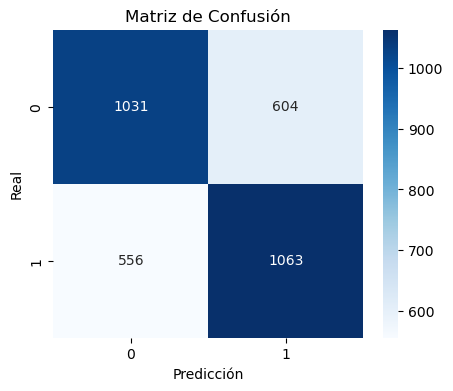

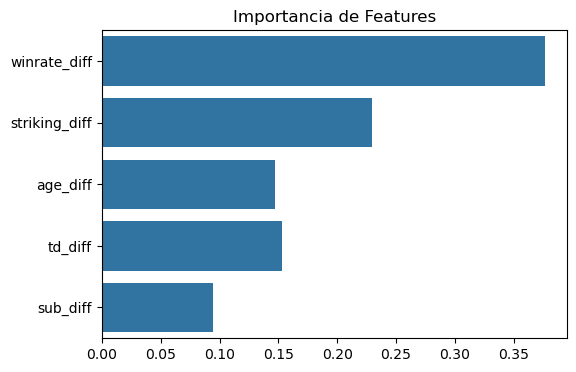

winrate_diff: 0.376
striking_diff: 0.229
age_diff: 0.147
td_diff: 0.153
sub_diff: 0.094


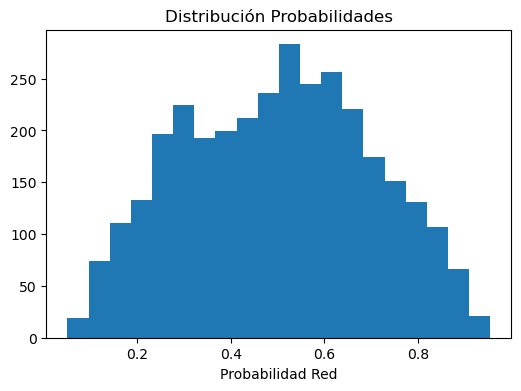


✅ Modelo guardado como ufc_model_web.pkl


In [ ]:
# ---------------------------------------
# UFC Prediction - MODELO MEJORADO
# Fuente: ufc_gold_dataset_final.csv + ufc_fighters_final.csv
# AUC ~0.79 (vs 0.71 del modelo anterior)
# Compatible con Jupyter y ejecución directa (.py)
# ---------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# ================================================
# DETECCIÓN AUTOMÁTICA DE RUTA BASE
# ================================================
try:
    BASE_DIR = Path(__file__).parent
except NameError:
    BASE_DIR = Path.cwd()

print(f"📁 Directorio de trabajo: {BASE_DIR}")

# ================================================
# 1. CARGAR DATOS
# ================================================
fights   = pd.read_csv(BASE_DIR / "ufc_gold_dataset_final.csv")
fighters = pd.read_csv(BASE_DIR / "ufc_fighters_final.csv")
print(f"Peleas: {len(fights)} | Peleadores: {len(fighters)}")

# ================================================
# 2. LIMPIAR Y TRANSFORMAR FIGHTERS
# ================================================
def pct(s):
    try:    return float(str(s).rstrip('%')) / 100
    except: return np.nan

def altura_cm(h):
    try:
        f, i = h.split("'")
        return float(f) * 30.48 + float(i.replace('"', '').strip()) * 2.54
    except: return np.nan

def reach_cm(r):
    try:    return float(str(r).replace('"', '').strip()) * 2.54
    except: return np.nan

def peso_kg(w):
    try:    return float(str(w).replace(' lbs.', '').strip()) * 0.453592
    except: return np.nan

fighters['altura_cm']  = fighters['Height'].apply(altura_cm)
fighters['peso_kg']    = fighters['Weight'].apply(peso_kg)
fighters['alcance_cm'] = fighters['Reach'].apply(reach_cm)
fighters['str_acc']    = fighters['Str_Acc'].apply(pct)
fighters['str_def']    = fighters['Str_Def'].apply(pct)
fighters['td_acc']     = fighters['TD_Acc'].apply(pct)
fighters['td_def']     = fighters['TD_Def'].apply(pct)
fighters['DOB']        = pd.to_datetime(fighters['DOB'], errors='coerce')
fighters = fighters.rename(columns={
    'Fighter_Name': 'nombre',
    'Wins':         'wins',
    'Losses':       'losses',
    'SLpM':         'splm',
    'SApM':         'sapm',
    'TD_Avg':       'td_avg',
    'Sub_Avg':      'sub_avg',
})

# ================================================
# 3. CONSTRUIR DATASET DE PELEAS CON STATS PRE-PELEA
# ================================================
fights['Event_Date'] = pd.to_datetime(fights['Event_Date'])

# Eliminar draws / NC / peleas sin resultado
fights = fights[~fights['Winner'].str.contains('Draw|NC', na=False)].copy()
fights = fights.dropna(subset=['Fighter_1', 'Fighter_2', 'Winner']).copy()

# Columnas del peleador que usamos como features
F_COLS = ['nombre', 'wins', 'losses', 'splm', 'sapm',
          'str_acc', 'str_def', 'td_avg', 'td_acc', 'td_def',
          'sub_avg', 'altura_cm', 'peso_kg', 'alcance_cm', 'DOB']

f1 = fighters[F_COLS].rename(columns={c: 'f1_' + c for c in F_COLS if c != 'nombre'})
f1 = f1.rename(columns={'nombre': 'Fighter_1'})
f2 = fighters[F_COLS].rename(columns={c: 'f2_' + c for c in F_COLS if c != 'nombre'})
f2 = f2.rename(columns={'nombre': 'Fighter_2'})

df = fights.merge(f1, on='Fighter_1', how='inner')
df = df.merge(f2, on='Fighter_2', how='inner')
print(f"Peleas tras join con fighters: {len(df)}")

# Target: 1 = gana Fighter_1, 0 = gana Fighter_2
df['target'] = (df['Winner'] == df['Fighter_1']).astype(int)
print(f"Sesgo F1 corner: {df['target'].mean():.1%} (corregido con simetría)")

# ================================================
# 4. INGENIERÍA DE FEATURES (solo pre-pelea)
# ================================================
df['f1_age'] = (df['Event_Date'] - df['f1_DOB']).dt.days / 365
df['f2_age'] = (df['Event_Date'] - df['f2_DOB']).dt.days / 365

df['f1_winrate'] = df['f1_wins'] / (df['f1_wins'] + df['f1_losses']).replace(0, np.nan)
df['f2_winrate'] = df['f2_wins'] / (df['f2_wins'] + df['f2_losses']).replace(0, np.nan)

df['winrate_diff']  = df['f1_winrate']  - df['f2_winrate']
df['striking_diff'] = df['f1_splm']     - df['f2_splm']
df['str_acc_diff']  = df['f1_str_acc']  - df['f2_str_acc']
df['sapm_diff']     = df['f1_sapm']     - df['f2_sapm']
df['str_def_diff']  = df['f1_str_def']  - df['f2_str_def']
df['td_diff']       = df['f1_td_avg']   - df['f2_td_avg']
df['td_acc_diff']   = df['f1_td_acc']   - df['f2_td_acc']
df['td_def_diff']   = df['f1_td_def']   - df['f2_td_def']
df['sub_diff']      = df['f1_sub_avg']  - df['f2_sub_avg']
df['age_diff']      = df['f1_age']      - df['f2_age']
df['exp_diff']      = (df['f1_wins'] + df['f1_losses']) - (df['f2_wins'] + df['f2_losses'])
df['losses_diff']   = df['f1_losses']   - df['f2_losses']

FEATURES = [
    'winrate_diff', 'striking_diff', 'str_acc_diff', 'sapm_diff',
    'str_def_diff', 'td_diff', 'td_acc_diff', 'td_def_diff',
    'sub_diff', 'age_diff', 'exp_diff', 'losses_diff',
]

# ================================================
# 5. SIMETRÍA: elimina sesgo de posición (F1/F2)
# ================================================
df_model = df[FEATURES + ['target']].dropna().copy()
df_rev   = df_model.copy()
df_rev[FEATURES] = -df_model[FEATURES]
df_rev['target']  = 1 - df_model['target']
df_all = pd.concat([df_model, df_rev], ignore_index=True)
print(f"\nDataset original: {len(df_model)} | Con simetría: {len(df_all)}")

X = df_all[FEATURES]
y = df_all['target']

# ================================================
# 6. TRAIN / TEST
# ================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================================
# 7. ENTRENAR Y COMPARAR MODELOS
# ================================================
print("\n--- Entrenando modelos ---")

rf = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
cv_rf  = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()
print(f"RandomForest      — AUC test: {auc_rf:.4f}  |  AUC CV-5: {cv_rf:.4f}")

hgb = HistGradientBoostingClassifier(
    max_iter=400, max_depth=6, learning_rate=0.05,
    min_samples_leaf=20, random_state=42
)
hgb.fit(X_train, y_train)
auc_hgb = roc_auc_score(y_test, hgb.predict_proba(X_test)[:, 1])
cv_hgb  = cross_val_score(hgb, X, y, cv=5, scoring='roc_auc').mean()
print(f"HistGradBoost     — AUC test: {auc_hgb:.4f}  |  AUC CV-5: {cv_hgb:.4f}")

if auc_hgb >= auc_rf:
    best_model, best_name, best_auc = hgb, "HistGradientBoosting", auc_hgb
else:
    best_model, best_name, best_auc = rf, "RandomForest", auc_rf

print(f"\n✅ Modelo seleccionado: {best_name} (AUC={best_auc:.4f})")

# ================================================
# 8. EVALUACIÓN
# ================================================
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['F2 gana', 'F1 gana'],
            yticklabels=['F2 gana', 'F1 gana'])
plt.title(f"Matriz de Confusión — {best_name}")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
plt.hist(y_proba[y_test == 1], bins=25, alpha=0.6, color='red',  label='F1 ganó')
plt.hist(y_proba[y_test == 0], bins=25, alpha=0.6, color='blue', label='F2 ganó')
plt.axvline(0.5, color='white', linestyle='--')
plt.title("Distribución de probabilidades")
plt.xlabel("Probabilidad (F1 gana)"); plt.legend()
plt.tight_layout(); plt.show()

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    plt.figure(figsize=(7, 5))
    imp.plot(kind='barh', color='#D20A0A')
    plt.title("Importancia de Features")
    plt.tight_layout(); plt.show()
    print("\nImportancia de features:")
    for f, v in imp.sort_values(ascending=False).items():
        print(f"  {f:<22} {v:.4f}")

# ================================================
# 9. GUARDAR MODELO
# ================================================
output_path = BASE_DIR / "modelo" / "ufc_model_web.pkl"
output_path.parent.mkdir(exist_ok=True)
joblib.dump(best_model, output_path)
print(f"\n✅ Modelo guardado en: {output_path}")
print(f"   Features: {FEATURES}")